In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely

%matplotlib inline  

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import numpy as np
import pandas as pd

from gsw import density

from load_meop import MEOP
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO

pfns = PlottingFns()

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [3]:
def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

In [4]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation


In [5]:
ds = xr.open_dataset(fname_zhou)
ds = ds.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})

In [6]:
extent =[100,160,-69,-62]
extent_mertz =[138.5,143,-67,-62]

In [7]:
clim_mertz = crop_to_extent(ds,extent_mertz)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


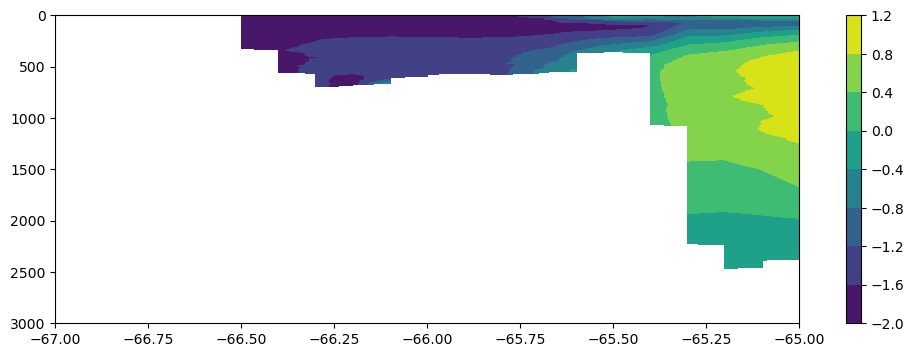

In [8]:
clim_139E = clim_mertz.where(clim_mertz.longitude==139,drop=True).squeeze()
fig, ax = plt.subplots(figsize=(12,4))
im=ax.contourf(clim_139E.latitude,clim_139E.pressure,clim_139E.ct)
ax.set_ylim([0,3000])
ax.invert_yaxis()
plt.colorbar(im)


In [8]:
dspira = xr.open_dataset(fname_spira)
dspira = dspira.swap_dims({'n_prof':'time'})
dspira_mertz = dspira.where(
    (dspira.lon > extent_mertz[0]) &
    (dspira.lon < extent_mertz[1]) &
    (dspira.lat > extent_mertz[2]) &
    (dspira.lat < extent_mertz[3]), drop=True
)

In [9]:
dspira_mertz

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 1530, pres: 501)
Coordinates:
    lon      (time) float64 12kB 142.5 142.9 140.0 140.0 ... 140.4 140.2 139.7
    lat      (time) float64 12kB -64.01 -64.25 -66.56 ... -63.21 -63.29 -63.32
  * time     (time) datetime64[ns] 12kB 2006-04-23T04:26:42 ... 2021-12-30T13...
    n_prof   (time) int64 12kB 119908 120445 793190 ... 298486 298443 298395
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp     (time, pres) float64 6MB nan nan nan -0.2566 ... 1.257 1.255 1.251
    psal     (time, pres) float64 6MB nan nan nan 33.95 ... 34.73 34.73 34.73
    dsource  (time) object 12kB 'Argo' 'Argo' 'MEOP' ... 'Argo' 'Argo' 'Argo'
    mld      (time) float64 12kB 83.76 78.81 65.34 17.82 ... 17.63 33.77 35.65
    asal     (time, pres) float32 3MB nan nan nan 34.11 ... 34.89 34.89 34.89
    ctemp    (time, pres) float32 3MB nan nan nan -0.2522 ... 1.257 1.255 1.251
    rho      (time, pres) float32 3MB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 12kB 82.0 78.0 52.0 14.0 ... 18.0 16.0 34.0 34.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [10]:
dspira_mertz['elevation'] = elevation.interp(latitude=dspira_mertz.lat,longitude=dspira_mertz.lon).drop(['longitude','latitude'])
dspira_mertz

/tmp/ipykernel_2693/2125194757.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  dspira_mertz['elevation'] = elevation.interp(latitude=dspira_mertz.lat,longitude=dspira_mertz.lon).drop(['longitude','latitude'])


<xarray.Dataset> Size: 22MB
Dimensions:    (time: 1530, pres: 501)
Coordinates:
    lon        (time) float64 12kB 142.5 142.9 140.0 140.0 ... 140.4 140.2 139.7
    lat        (time) float64 12kB -64.01 -64.25 -66.56 ... -63.21 -63.29 -63.32
  * time       (time) datetime64[ns] 12kB 2006-04-23T04:26:42 ... 2021-12-30T...
    n_prof     (time) int64 12kB 119908 120445 793190 ... 298486 298443 298395
  * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp       (time, pres) float64 6MB nan nan nan ... 1.257 1.255 1.251
    psal       (time, pres) float64 6MB nan nan nan 33.95 ... 34.73 34.73 34.73
    dsource    (time) object 12kB 'Argo' 'Argo' 'MEOP' ... 'Argo' 'Argo' 'Argo'
    mld        (time) float64 12kB 83.76 78.81 65.34 17.82 ... 17.63 33.77 35.65
    asal       (time, pres) float32 3MB nan nan nan 34.11 ... 34.89 34.89 34.89
    ctemp      (time, pres) float32 3MB nan nan nan ... 1.257 1.255 1.251
    rho        (time, pres) float32 3MB nan nan nan ... 1.028e+03 1.028e+03
    mlp        (time) float64 12kB 82.0 78.0 52.0 14.0 ... 18.0 16.0 34.0 34.0
    elevation  (time) float64 12kB -3.77e+03 -3.672e+03 ... -3.773e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

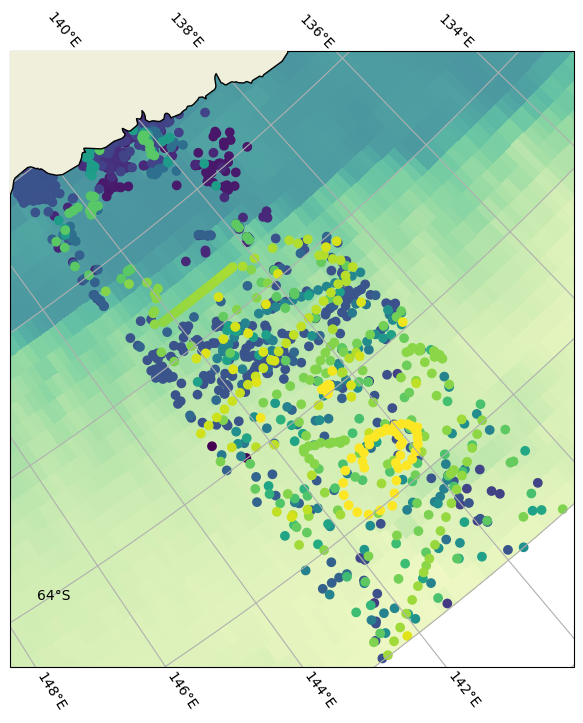

In [11]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(dspira_mertz.lon,dspira_mertz.lat,c=dspira_mertz.time,transform=ccrs.PlateCarree())
#ax.legend()

In [12]:
dspira_mertz['month'] = dspira_mertz.time.dt.month
dspira_mertz['sigma0'] = density.sigma0(dspira_mertz.asal,dspira_mertz.ctemp)+1000

In [13]:
dspira_mertz

<xarray.Dataset> Size: 28MB
Dimensions:    (time: 1530, pres: 501)
Coordinates:
    lon        (time) float64 12kB 142.5 142.9 140.0 140.0 ... 140.4 140.2 139.7
    lat        (time) float64 12kB -64.01 -64.25 -66.56 ... -63.21 -63.29 -63.32
  * time       (time) datetime64[ns] 12kB 2006-04-23T04:26:42 ... 2021-12-30T...
    n_prof     (time) int64 12kB 119908 120445 793190 ... 298486 298443 298395
  * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp       (time, pres) float64 6MB nan nan nan ... 1.257 1.255 1.251
    psal       (time, pres) float64 6MB nan nan nan 33.95 ... 34.73 34.73 34.73
    dsource    (time) object 12kB 'Argo' 'Argo' 'MEOP' ... 'Argo' 'Argo' 'Argo'
    mld        (time) float64 12kB 83.76 78.81 65.34 17.82 ... 17.63 33.77 35.65
    asal       (time, pres) float32 3MB nan nan nan 34.11 ... 34.89 34.89 34.89
    ctemp      (time, pres) float32 3MB nan nan nan ... 1.257 1.255 1.251
    rho        (time, pres) float32 3MB nan nan nan ... 1.028e+03 1.028e+03
    mlp        (time) float64 12kB 82.0 78.0 52.0 14.0 ... 18.0 16.0 34.0 34.0
    elevation  (time) float64 12kB -3.77e+03 -3.672e+03 ... -3.773e+03
    month      (time) int64 12kB 4 5 2 2 2 2 2 2 2 ... 12 12 12 12 12 12 12 12
    sigma0     (time, pres) float64 6MB nan nan nan ... 1.028e+03 1.028e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [14]:
    
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons=get_seasons(dspira_mertz)


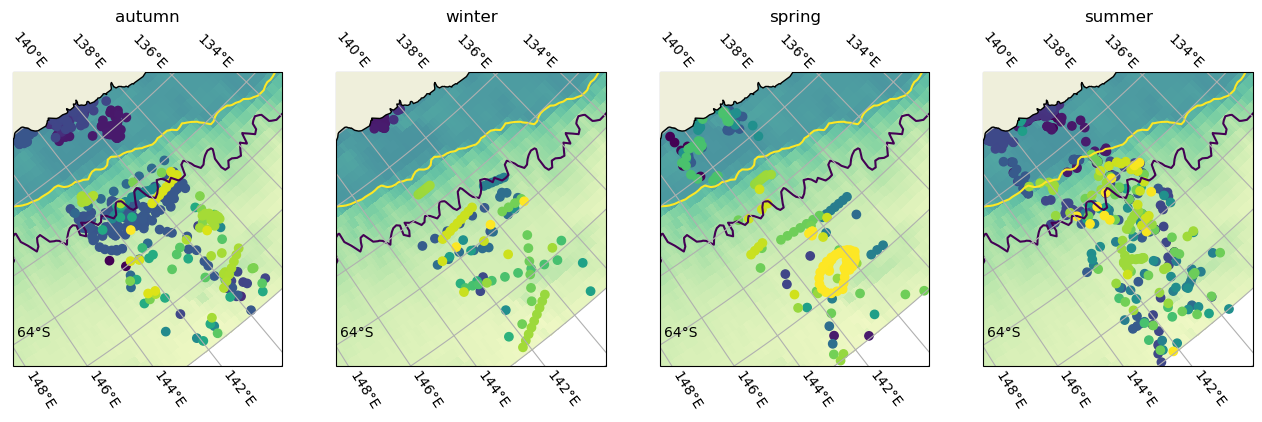

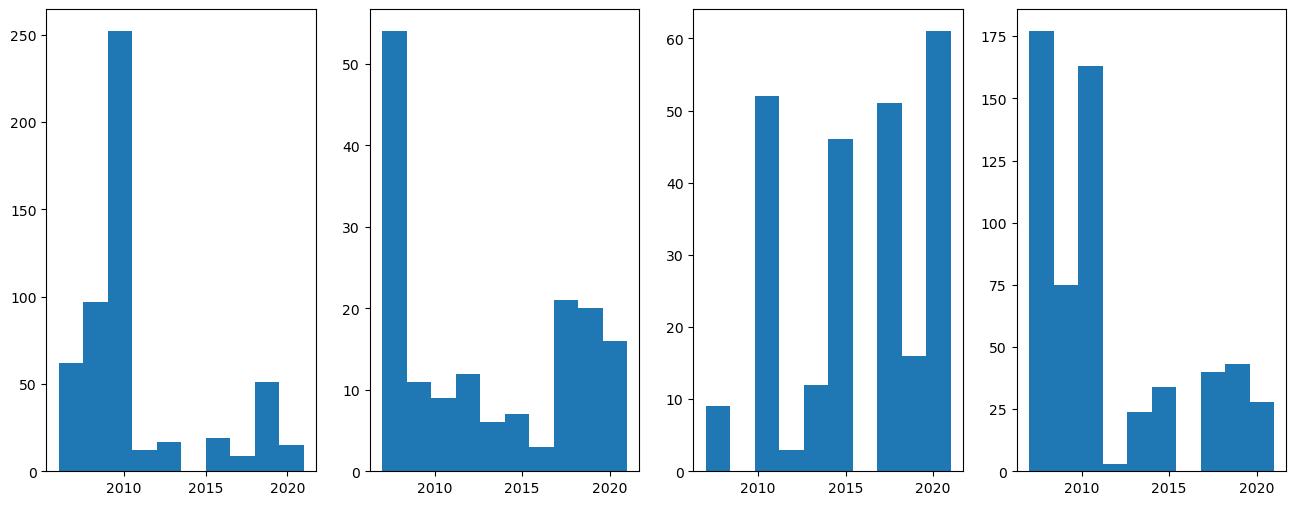

In [15]:
fig,ax=plt.subplots(1,4,figsize=(16,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
for n,s in enumerate(seasons):
    pfns.sp(ax[n],elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
    im=ax[n].scatter(seasons[s].lon,seasons[s].lat,c=seasons[s].time,transform=ccrs.PlateCarree())
    ax[n].set_title(s)
    ax[n].contour(elevation.longitude,elevation.latitude, elevation,levels=[-3000,-1000],transform=ccrs.PlateCarree())
    
fig,ax=plt.subplots(1,4,figsize=(16,6))
for n,s in enumerate(seasons):
    ax[n].hist(seasons[s].time.dt.year)

In [18]:
seasons['summer'].where(seasons['summer'].elevation < -1000,drop=True).temp.mean('time')

<xarray.DataArray 'temp' (pres: 501)> Size: 4kB
array([ 2.11752633e+00,  1.61868078e+00,  1.02947759e+00,  9.47690325e-01,
        9.07823325e-01,  8.97332100e-01,  8.88987233e-01,  8.82187872e-01,
        8.74629564e-01,  8.58490954e-01,  8.46085068e-01,  8.30881609e-01,
        8.07158140e-01,  7.80609806e-01,  7.45055225e-01,  7.06250816e-01,
        6.60489466e-01,  5.98115278e-01,  5.06063622e-01,  3.94970343e-01,
        2.75933887e-01,  1.38184868e-01,  1.33204383e-03, -1.21076652e-01,
       -2.30392532e-01, -3.37055448e-01, -4.34609975e-01, -5.02867281e-01,
       -5.65641764e-01, -6.20627662e-01, -6.63253789e-01, -6.98825691e-01,
       -7.21662755e-01, -7.35475956e-01, -7.37117719e-01, -7.37718620e-01,
       -7.19108069e-01, -6.94783933e-01, -6.62689749e-01, -6.27007171e-01,
       -5.87231380e-01, -5.47275229e-01, -5.01689623e-01, -4.56569065e-01,
       -4.03582799e-01, -3.48416768e-01, -3.03584828e-01, -2.53152281e-01,
       -2.03468404e-01, -1.49888588e-01, -9.85637849e-02, -5.07411036e-02,
       -1.36790238e-03,  4.17564138e-02,  7.41317789e-02,  1.01081676e-01,
        1.36281486e-01,  1.72574097e-01,  2.10891939e-01,  2.45951516e-01,
        2.74630572e-01,  3.07457960e-01,  3.40983933e-01,  3.68132741e-01,
        3.98046257e-01,  4.20825717e-01,  4.41108793e-01,  4.59294674e-01,
        4.78170233e-01,  4.94490827e-01,  5.14855924e-01,  5.33528486e-01,
        5.50358520e-01,  5.70199405e-01,  5.89238229e-01,  6.05926722e-01,
        6.23022040e-01,  6.41459233e-01,  6.56603418e-01,  6.73506229e-01,
...
        1.18526219e+00,  1.18312941e+00,  1.18127348e+00,  1.17963806e+00,
        1.17796555e+00,  1.17658955e+00,  1.17465013e+00,  1.17212604e+00,
        1.17025209e+00,  1.16847151e+00,  1.16698356e+00,  1.16529047e+00,
        1.16670011e+00,  1.17174865e+00,  1.17038382e+00,  1.16879984e+00,
        1.16745260e+00,  1.16601923e+00,  1.16458200e+00,  1.16318095e+00,
        1.16117119e+00,  1.15904501e+00,  1.15671779e+00,  1.15500701e+00,
        1.15310203e+00,  1.15121748e+00,  1.14968702e+00,  1.14826030e+00,
        1.14634801e+00,  1.14475095e+00,  1.14372340e+00,  1.14264479e+00,
        1.14132877e+00,  1.13989812e+00,  1.13801796e+00,  1.13645474e+00,
        1.13430685e+00,  1.13250207e+00,  1.13079924e+00,  1.12902318e+00,
        1.12707602e+00,  1.12576613e+00,  1.12416567e+00,  1.12218081e+00,
        1.12038834e+00,  1.11917954e+00,  1.11776530e+00,  1.11630279e+00,
        1.11447986e+00,  1.11267348e+00,  1.11104824e+00,  1.10942589e+00,
        1.10768781e+00,  1.10611762e+00,  1.10462836e+00,  1.10289620e+00,
        1.10147278e+00,  1.10032463e+00,  1.09846223e+00,  1.09609216e+00,
        1.09434207e+00,  1.09258771e+00,  1.09085749e+00,  1.08904791e+00,
        1.08779691e+00,  1.07808408e+00,  1.08310718e+00,  1.08112445e+00,
        1.07938105e+00,  1.07750737e+00,  1.07616072e+00,  1.07417321e+00,
        1.08202945e+00,  1.08021168e+00,  1.07649513e+00,  1.07498442e+00,
        1.07035412e+00])
Coordinates:
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000

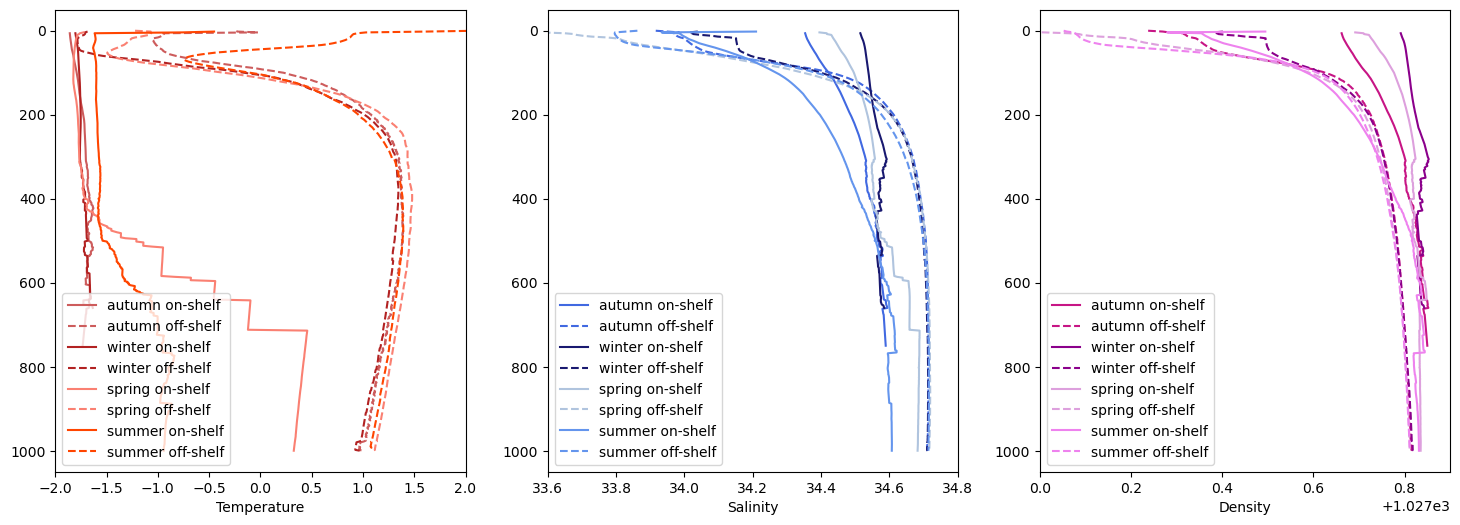

In [30]:
fig, ax = plt.subplots(1,3,figsize=(18,6))
def plot_var(ax,var,title,c,ylim):
    for i,s in enumerate(seasons):
        #get onslope profile
        data=seasons[s].where(seasons[s].elevation > -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'-',c=c[i],label=s + ' on-shelf')
        #get offslope profile
        data=seasons[s].where(seasons[s].elevation < -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'--',c=c[i],label=s+' off-shelf')
    ax.invert_yaxis()
    ax.set_xlim(ylim)
    ax.set_xlabel(title)
    ax.legend(loc='lower left')



plot_var(ax[0],'temp','Temperature',['indianred','firebrick','salmon','orangered'],[-2,2])
plot_var(ax[1],'psal','Salinity',['royalblue','midnightblue','lightsteelblue','cornflowerblue'],[33.6,34.8])
plot_var(ax[2],'sigma0','Density',['mediumvioletred','darkmagenta','plum','violet'],[1027,1027.9])



In [15]:
seasons['spring'].where(seasons['spring'].lat<-66)

<xarray.Dataset> Size: 5MB
Dimensions:  (lat: 250, pres: 501)
Coordinates:
    lon      (lat) float64 2kB 142.7 143.0 142.6 142.3 ... 140.4 140.2 139.7
  * lat      (lat) float64 2kB -66.0 -66.34 -66.33 ... -63.21 -63.29 -63.32
    time     (lat) datetime64[ns] 2kB 2007-12-22T23:13:31.999511552 ... 2021-...
    n_prof   (lat) int64 2kB 568086 568092 568093 ... 298486 298443 298395
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp     (lat, pres) float64 1MB nan nan -0.6258 -0.6099 ... nan nan nan nan
    psal     (lat, pres) float64 1MB nan nan 34.22 34.21 ... nan nan nan nan
    dsource  (lat) object 2kB 'CTD' 'CTD' 'CTD' 'CTD' 'CTD' ... nan nan nan nan
    mld      (lat) float64 2kB 15.84 15.84 27.72 19.8 81.17 ... nan nan nan nan
    asal     (lat, pres) float32 501kB nan nan 34.38 34.38 ... nan nan nan nan
    ctemp    (lat, pres) float32 501kB nan nan -0.6223 -0.6064 ... nan nan nan
    rho      (lat, pres) float32 501kB nan nan 1.028e+03 ... nan nan nan
    mlp      (lat) float64 2kB 16.0 10.0 28.0 18.0 90.0 ... nan nan nan nan nan
    month    (lat) float64 2kB 12.0 12.0 12.0 12.0 12.0 ... nan nan nan nan nan
    sigma0   (lat, pres) float64 1MB nan nan 1.028e+03 1.028e+03 ... nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [16]:
average_elevation = elevation.sel(longitude=slice(138,140.5)).min('longitude')


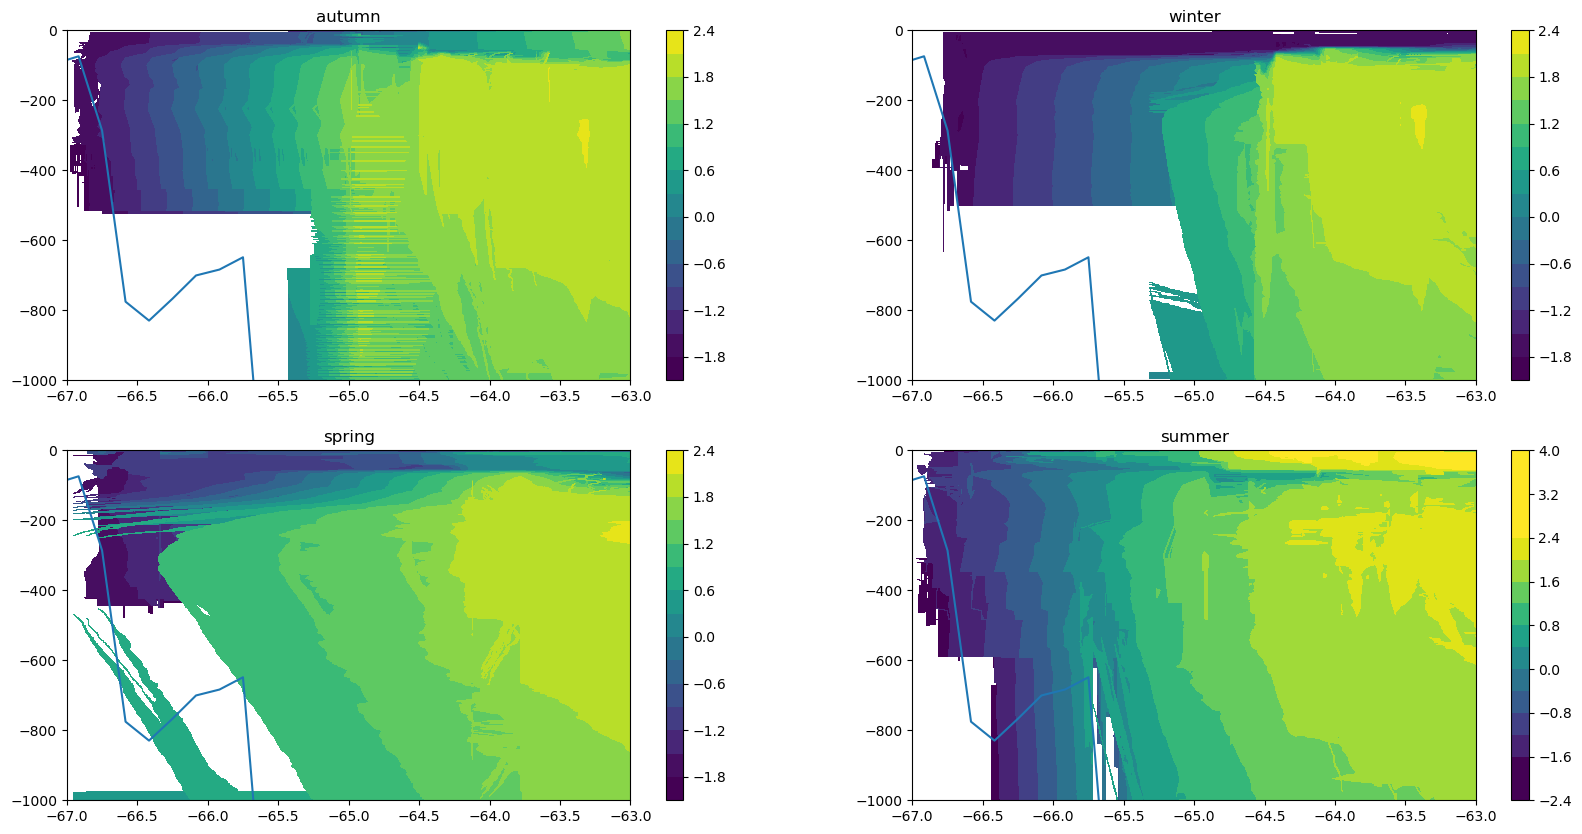

In [17]:
fig,ax = plt.subplots(2,2,figsize=(20,10))

ax = ax.flat
for n,s in enumerate(seasons):
    ax[n].plot(average_elevation.latitude,average_elevation)

    temp = seasons[s].temp.T
    im=ax[n].contourf(seasons[s].lat,-seasons[s].pres,temp,vmax=2.4,vmin=-1.8,levels=15)
    ax[n].set_xlim([-67,-63])
    ax[n].set_ylim([-1000,0])

    ax[n].set_title(s)
    plt.colorbar(im)

# mask = ~np.isnan(temp.values)
# pres2d,lat2d = np.meshgrid(summer.pres,summer.lat,indexing='ij')
#ax.scatter(lat2d[mask],-pres2d[mask],marker='x',color='k')

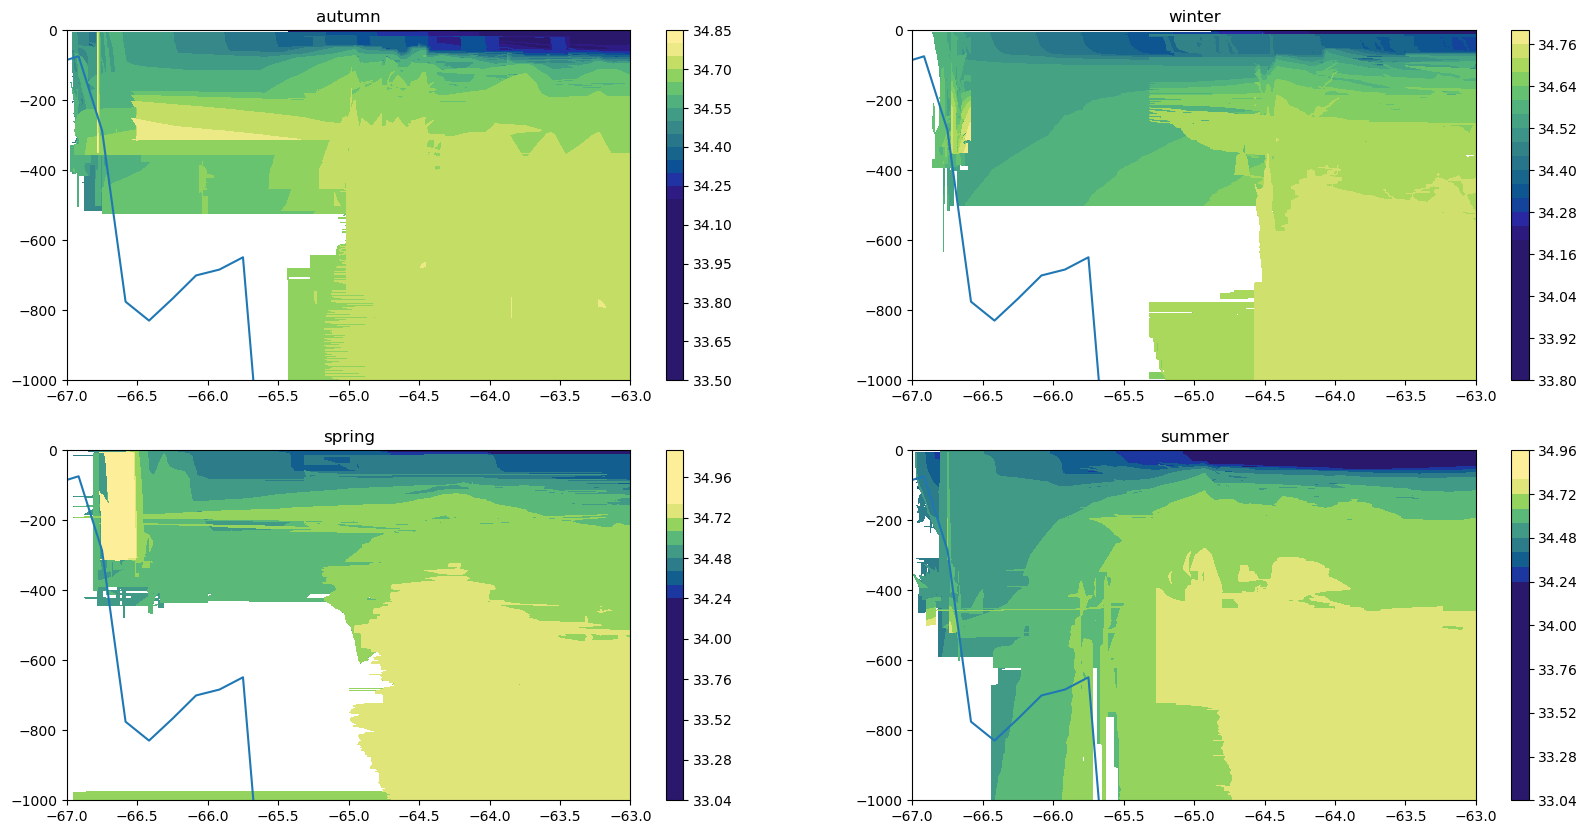

In [18]:
fig,ax = plt.subplots(2,2,figsize=(20,10))

ax = ax.flat
for n,s in enumerate(seasons):
    ax[n].plot(average_elevation.latitude,average_elevation)

    psal = seasons[s].psal.T
    im=ax[n].contourf(seasons[s].lat,-seasons[s].pres,psal,vmax=34.8,vmin=34.2,levels=25,cmap=cmocean.cm.haline)
    ax[n].set_xlim([-67,-63])
    ax[n].set_ylim([-1000,0])

    ax[n].set_title(s)
    plt.colorbar(im)


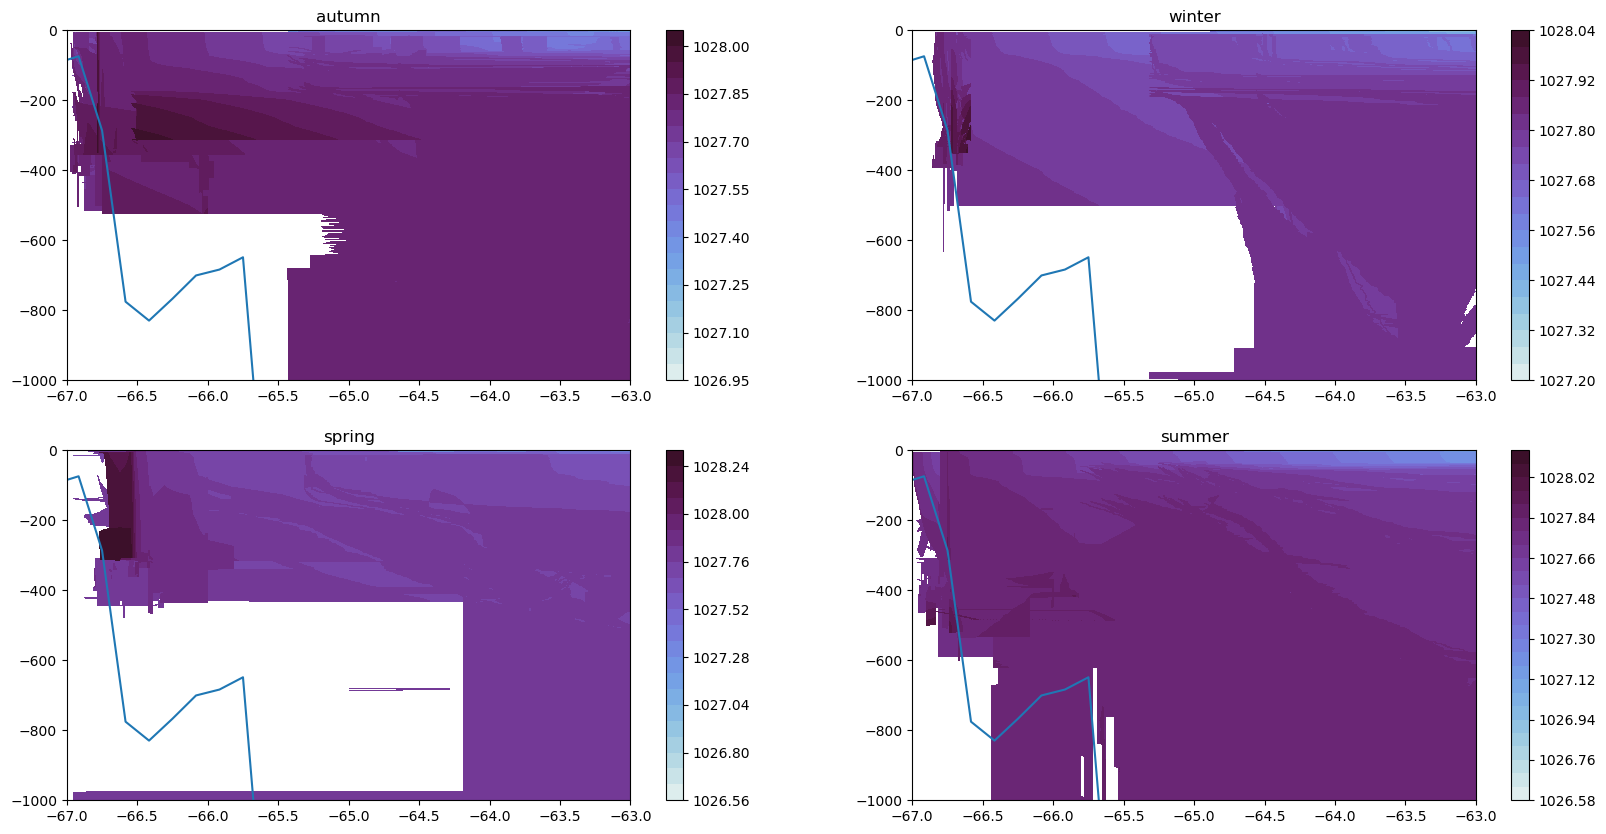

In [19]:
fig,ax = plt.subplots(2,2,figsize=(20,10))

ax = ax.flat
for n,s in enumerate(seasons):
    ax[n].plot(average_elevation.latitude,average_elevation)

    rho = seasons[s].sigma0.T
    im=ax[n].contourf(seasons[s].lat,-seasons[s].pres,rho,levels=25,cmap=cmocean.cm.dense)
    ax[n].set_xlim([-67,-63])
    ax[n].set_ylim([-1000,0])

    ax[n].set_title(s)
    plt.colorbar(im)


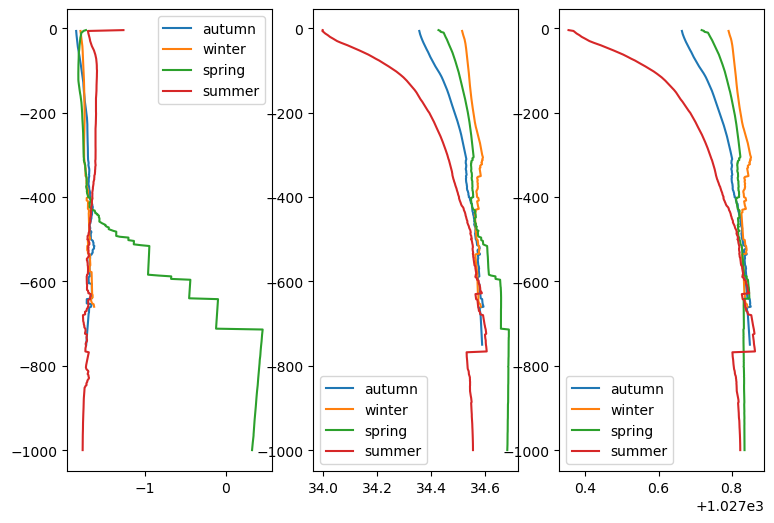

In [20]:
fig,ax = plt.subplots(1,3,figsize=(9,6))

for n,s in enumerate(seasons):
    da = seasons[s].where(seasons[s].lat < -66,drop=True).where(seasons[s].pres > 2,drop=True).mean('lat')
    ax[0].plot(da.temp,-da.pres,label=s)
    ax[1].plot(da.psal,-da.pres,label=s)
    ax[2].plot(da.sigma0,-da.pres,label=s)

ax[0].legend()
ax[1].legend()
ax[2].legend()


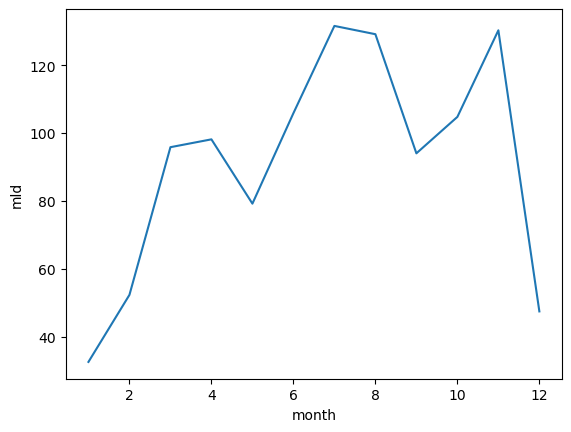

In [21]:
dspira_mertz.groupby('time.month').mean().mld.plot()
